# NLP From Scratch: 문자 단위(Character-Level) RNN으로 이름 분류하기

단어(이름)를 분류하기 위해 기본적인 문자 단위 RNN(Recurrent Neural Network, 순환 신경망)을 직접 구축하고 학습시켜 보겠습니다.

**문자를 단위로 단어를 읽고, 각 단계마다 예측값과 "은닉 상태(hidden state)"를 출력하며, 이전 은닉 상태를 다음 단계 입력으로 전달하는 방식**을 설명합니다. 최종 예측값을 해당 단어가 어떤 클래스(언어)에 속하는지로 사용합니다.

구체적으로, 18개 언어에서 가져온 수천 개의 성(姓, surname) 데이터를 학습해, 철자(스펠링)에 따라 이름이 어떤 언어에서 유래했는지 예측하는 모델을 만들어 봅니다.

In [1]:
from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset

# CUDA 사용 가능 여부 확인
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

torch.set_default_device(device)
print(f"Using device = {torch.get_default_device()}")

Using device = cuda:0


# 데이터 준비하기

데이터는 [여기](https://download.pytorch.org/tutorial/data.zip)에서 다운로드하여 현재 디렉토리에 압축을 풀어주세요.

`data/names` 디렉토리에는 `[Language].txt`라는 이름의 18개 텍스트 파일이 포함되어 있습니다. 각 파일에는 여러 개의 이름이 줄 단위로 들어 있으며, 대부분 로마자 표기(romanized)로 되어 있습니다. (하지만 여전히 Unicode → ASCII 변환이 필요합니다.)

첫 번째 단계는 데이터를 정의하고 정리(clean)하는 것입니다. 우선, RNN 입력 계층을 단순화하기 위해 **Unicode를 순수 ASCII로 변환**해야 합니다. 이는 Unicode 문자열을 ASCII 문자열로 변환하고, 허용된 문자 집합(small set of allowed characters)만 남기는 방식으로 수행합니다.


In [2]:
# data.zip 다운로드
!wget https://download.pytorch.org/tutorial/data.zip

# 압축 해제
!unzip data.zip

--2025-09-09 20:15:36--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 3.165.102.36, 3.165.102.113, 3.165.102.62, ...
Connecting to download.pytorch.org (download.pytorch.org)|3.165.102.36|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip.1’

data.zip.1          100%[===================>]   2.75M  --.-KB/s    in 0.01s   

2025-09-09 20:15:36 (209 MB/s) - ‘data.zip.1’ saved [2882130/2882130]

Archive:  data.zip
replace data/eng-fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: data/eng-fra.txt        
replace data/names/Arabic.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: data/names/Arabic.txt   
replace data/names/Chinese.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: data/names/Chinese.txt  
replace data/names/Czech.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/names/Czech.txt    
replace data/

In [3]:
import string
import unicodedata

# 모델에서 다루지 않는 문자(어휘 사전에 없는 문자)는 "_"로 표시할 수 있다
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)

print(allowed_characters)
print(n_letters)

# 유니코드 문자열을 일반 ASCII 문자열로 변환
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,;'_
58


유니코드 알파벳 이름을 일반 ASCII로 변환하는 예시입니다.
이렇게 하면 입력 계층이 단순해집니다.

In [4]:
print (f"converting 'Ślusàrski' to {unicodeToAscii('Ślusàrski')}")

converting 'Ślusàrski' to Slusarski


이름을 텐서로 변환하기
==========================

이제 모든 이름들이 정리되었으므로, 이를 활용하기 위해 텐서로 변환해야 합니다.

단일 문자를 표현하기 위해 `<1 x n_letters>` 크기의 "원-핫 벡터(one-hot vector)"를 사용합니다.  
원-핫 벡터는 현재 문자의 인덱스 위치에만 1이 있고 나머지는 모두 0으로 채워진 벡터입니다. 예를 들어 `"b" = <0 1 0 0 0 ...>`와 같습니다.  
PyTorch RNN은 입력을 (seq_len, batch, input_size) 형태로 받으므로,
단어를 만들기 위해 이러한 벡터들을 3D 행렬 `<line_length x 1 x n_letters>`로 결합합니다.

In [5]:
# all_letters에서 문자 인덱스 찾기, 예: "a" = 0
def letterToIndex(letter):
    # 모델이 알지 못하는 문자를 만나면 어휘 사전 밖의 문자를 반환
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

# 라인을 <line_length x 1 x n_letters>로 변환,
# 또는 원-핫 문자 벡터의 배열로 변환
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

단일 문자와 여러 문자 문자열에 대해 `lineToTensor()`를 사용하는 예시들입니다.

In [6]:
print (f"The letter 'a' becomes {lineToTensor('a')}")  # 텐서에서 첫 번째 위치가 1이 되는 것을 확인
print (f"The name 'Ahn' becomes {lineToTensor('Ahn')}")  # 'A'가 27번째 인덱스를 1로 설정하는 것을 확인

The letter 'a' becomes tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]]], device='cuda:0')
The name 'Ahn' becomes tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 

Dataset 클래스를 사용하여 데이터셋을 정의합니다.  
각 Dataset은 `__init__`, `__len__`, `__getitem__` 세 가지 함수를 구현해야 합니다.

In [7]:
text_files = glob.glob(os.path.join("data/names", '*.txt'))
os.path.splitext(os.path.basename(text_files[0]))

('French', '.txt')

In [8]:
class NamesDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir   # 데이터셋의 출처 기록용
        labels_set = set()         # 모든 클래스(label)의 집합

        self.data = []             # 이름 데이터
        self.data_tensors = []     # 이름 데이터를 텐서로 변환한 것
        self.labels = []           # 각 이름 데이터의 라벨(언어)
        self.labels_tensors = []   # 라벨을 텐서로 변환한 것

        # 지정된 디렉토리 내 모든 .txt 파일 읽기
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            # 파일명에서 확장자를 제거한 부분을 label로 사용 (예: English, Korean 등)
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)

            # 파일 내용을 줄 단위로 읽기
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)                # 원본 이름
                self.data_tensors.append(lineToTensor(name))  # 이름을 텐서로 변환
                self.labels.append(label)             # 해당 이름의 언어 라벨

        # 라벨을 텐서로 변환하여 캐시
        self.labels_uniq = list(labels_set)           # 고유한 라벨 목록
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor(
                [self.labels_uniq.index(self.labels[idx])],
                dtype=torch.long
            )
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        # 전체 데이터 개수 반환
        return len(self.data)

    def __getitem__(self, idx):
        # 주어진 인덱스의 데이터와 라벨 반환
        data_item = self.data[idx]             # 이름
        data_label = self.labels[idx]          # 라벨(언어)
        data_tensor = self.data_tensors[idx]   # 이름의 텐서 표현
        label_tensor = self.labels_tensors[idx]   # 라벨의 텐서 표현

        return label_tensor, data_tensor, data_label, data_item

여기서 예시 데이터를 `NamesDataset`에 로드할 수 있습니다.  
(예시) 이름 "Abel"의 문자 분석  
A → 1번째 문자  
b → 2번째 문자  
e → 3번째 문자  
l → 4번째 문자  

In [9]:
alldata = NamesDataset("data/names")
print(f"loaded {len(alldata)} items of data")
print(f"example = {alldata[0]}")

loaded 20074 items of data
example = (tensor([1], device='cuda:0'), tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.,

In [10]:
alldata[0][1].shape

torch.Size([4, 1, 58])

데이터셋 객체를 사용하면 데이터를 쉽게 훈련 세트와 테스트 세트로 분할할 수 있습니다.
여기서는 80/20 분할을 생성하지만 `torch.utils.data`에는 더 유용한 유틸리티들이 있습니다.
여기서는 PyTorch가 위에서 기본값으로 사용하는 것과 동일한 디바이스를 사용해야 하므로
제너레이터를 지정합니다.

In [11]:
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator(device=device).manual_seed(2024))

print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 17063, validation examples = 3011


이제 각 예시가 레이블과 이름의 쌍인 **20074**개의 예시를 포함하는 기본 데이터셋을 가지고 있습니다.
구축한 모델을 검증할 수 있도록 데이터셋을 훈련용과 테스트용으로 분할했습니다.

네트워크 생성하기
====================  
 RNN 은닉 레이어를 출력으로 매핑하는 레이어를 정의하고 마지막으로 `softmax` 함수를 적용합니다.  

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # 단일 RNN 레이어 (입력 크기 → 은닉 크기)
        # 입력: (seq_len, batch, input_size)
        # 출력: (seq_len, batch, hidden_size), hidden state
        self.lstm = nn.LSTM(input_size, hidden_size)

        # 은닉 상태(hidden state)를 최종 출력 크기(class 개수)로 변환하는 Linear 레이어
        self.h2o = nn.Linear(hidden_size, output_size)

        # 출력값을 확률 분포로 해석하기 위해 LogSoftmax 적용
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        # line_tensor: (seq_len, batch, input_size)
        # rnn_out: (seq_len, batch, hidden_size)
        # hidden: (num_layers, batch, hidden_size)
        lstm_out, (hidden, cell) = self.lstm(line_tensor)

        # hidden[0]: 마지막 은닉 상태 (batch, hidden_size)
        output = self.h2o(hidden[0])

        # 최종 출력에 LogSoftmax 적용
        output = self.softmax(output)

        return output

그러면 58개의 입력 노드, 128개의 은닉 노드, 18개의 출력을 가진 RNN을 생성할 수 있습니다:

In [14]:
n_hidden = 128
rnn = CharLSTM(n_letters, n_hidden, len(alldata.labels_uniq))
print(rnn)

CharLSTM(
  (lstm): LSTM(58, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


그 후 텐서를 RNN에 전달하여 예측된 출력을 얻을 수 있습니다.  
이어서 클래스에 대한 텍스트 레이블을 도출하기 위해 도우미 함수인 `label_from_output`를 사용하여 네트웍이 잘 작동하는지 test 해 봅니다.

In [15]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = lineToTensor('Albert')
output = rnn(input)    #  ``output = rnn.forward(input)``와 동일
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.9330, -2.8512, -2.9577, -2.8512, -2.9195, -2.9089, -2.9460, -2.9068,
         -2.9164, -2.8093, -2.8225, -2.8421, -2.9783, -2.9529, -2.9106, -2.8562,
         -2.8217, -2.8658]], device='cuda:0', grad_fn=<LogSoftmaxBackward0>)
('Vietnamese', 9)


훈련
========

In [16]:
import random
import numpy as np

def train(rnn, training_data, n_epoch = 10, n_batch_size = 64, report_every = 50, learning_rate = 0.2, criterion = nn.NLLLoss()):
    """
    지정된 반복 횟수와 보고 임계값에 대해 훈련 데이터 배치에서 학습
    """
    # 그래프 그리기를 위한 손실 추적
    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    start = time.time()
    print(f"training on data set with n = {len(training_data)}")

    for iter in range(1, n_epoch + 1):
        rnn.zero_grad()

        # 미니배치 생성
        # 각 이름의 길이가 다르기 때문에 데이터로더를 사용할 수 없습니다
        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches) //n_batch_size )

        for idx, batch in enumerate(batches):
            batch_loss = 0
            for i in batch: # 이 배치의 각 예시에 대해
                (label_tensor, text_tensor, label, text) = training_data[i]
                output = rnn.forward(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            # 매개변수 최적화
            batch_loss.backward()
            # 역전파 시 그래디언트 폭발 문제를 방지하기 위해
            # RNN 파라미터의 그래디언트 norm을 최대 3으로 클리핑
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        all_losses.append(current_loss / len(batches) )
        if iter % report_every == 0:
            print(f"{iter} ({iter / n_epoch:.0%}): \t average batch loss = {all_losses[-1]}")
        current_loss = 0

    return all_losses

In [17]:
start = time.time()
all_losses = train(rnn, train_set, n_epoch=27, learning_rate=0.15, report_every=5)
end = time.time()
print(f"training took {end-start}s")

training on data set with n = 17063
5 (19%): 	 average batch loss = 0.9033474664939077
10 (37%): 	 average batch loss = 0.6659111601552086
15 (56%): 	 average batch loss = 0.5264978215477589
20 (74%): 	 average batch loss = 0.42767695038131787
25 (93%): 	 average batch loss = 0.33710310249279657
training took 537.4638159275055s


결과 그래프 그리기
====================

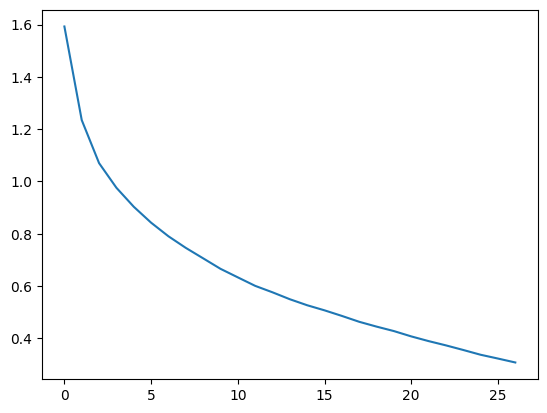

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

결과 평가하기
======================

네트워크가 다른 카테고리에서 얼마나 잘 수행하는지 보기 위해 혼동 행렬(confusion matrix)을 생성하겠습니다.  
이는 모든 실제 언어(행)에 대해 네트워크가 어떤 언어를 추측하는지(열)를 나타냅니다.


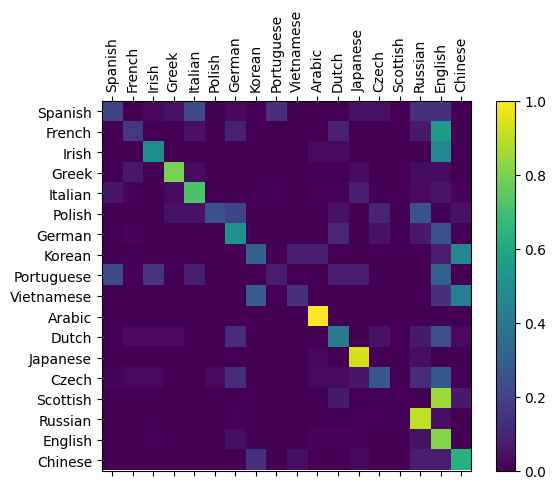

In [19]:
def evaluate(rnn, testing_data, classes):
    confusion = torch.zeros(len(classes), len(classes))

    rnn.eval()    # 평가 모드로 설정
    with torch.inference_mode():   # 평가 단계에서 그래디언트 기록하지 않음
        for i in range(len(testing_data)):
            (label_tensor, text_tensor, label, text) = testing_data[i]
            output = rnn(text_tensor)
            guess, guess_i = label_from_output(output, classes)
            label_i = classes.index(label)
            confusion[label_i][guess_i] += 1

    # 각 행을 그 합으로 나누어 정규화
    for i in range(len(classes)):
        denom = confusion[i].sum()
        if denom > 0:
            confusion[i] = confusion[i] / denom

    # 그래프 설정
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy()) # numpy는 여기서 cpu를 사용하므로 cpu 버전을 사용해야 합니다
    fig.colorbar(cax)

    # 축 설정
    ax.set_xticks(np.arange(len(classes)), labels=classes, rotation=90)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    # 모든 틱에서 레이블 강제 표시
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # sphinx_gallery_thumbnail_number = 2
    plt.show()

evaluate(rnn, test_set, classes=alldata.labels_uniq)

주 대각선에서 벗어난 밝은 점들을 찾아서 어떤 언어를 잘못 추측하는지 볼 수 있습니다.
예를 들어 한국어를 중국어로, 이탈리아어를 스페인어로 추측하는 경우가 있습니다.
그리스어에서는 매우 잘 작동하는 것 같고, 영어에서는 매우 성능이 좋지 않습니다
(아마도 다른 언어들과의 겹침 때문일 것입니다).

연습 문제
=========

-   더 크고/또는 더 잘 설계된 네트워크로 더 나은 결과 얻기
    -   에포크 수, 배치 크기, 학습률 변경과 같은 성능을 향상시키기 위해 하이퍼파라미터 조정
    -   `nn.LSTM`과 `nn.GRU` 레이어 시도해보기
    -   은닉 노드 수 증가 또는 감소, 추가 선형 레이어 추가와 같은 레이어 크기 수정
    -   이러한 RNN들을 여러 개 결합하여 더 높은 수준의 네트워크 구성
-   다른 라인 → 레이블 데이터셋으로 시도해보기, 예를 들어:
    -   임의의 단어 → 언어
    -   이름 → 성별
    -   캐릭터 이름 → 작가
    -   페이지 제목 → 블로그 또는 서브레딧